# Affichage des samples et des transformations


### Raw samples

In [2]:
## lecture des samples raws
import pandas as pd

path = "raw_samples/samples_raw.parquet"

df = pd.read_parquet(path)  
print("Rows:", len(df))
print("Columns:", list(df.columns))
print("\nDtypes:")
print(df.dtypes)
print("\nHead:")
display(df.head(10))


Rows: 2100
Columns: ['sample_id', 'sample_type', 'class_id', 'transform_id', 'class_name', 'file_name', 'file_path', 'image_bytes', 'image_hash', 'split']

Dtypes:
sample_id       object
sample_type     object
class_id         int64
transform_id     int64
class_name      object
file_name       object
file_path       object
image_bytes     object
image_hash      object
split           object
dtype: object

Head:


,sample_id,sample_type,class_id,transform_id,class_name,file_name,file_path,image_bytes,image_hash,split
0,agricultural_agricultural00,raw,0,0,agricultural,agricultural00.tif,../../data/UCMerced_LandUse/Images/agricultura...,b'II*\x00\x08\x00\x00\x00\x13\x00\xfe\x00\x04\...,85ac47bf0b3e840a,train
1,agricultural_agricultural01,raw,0,0,agricultural,agricultural01.tif,../../data/UCMerced_LandUse/Images/agricultura...,b'II*\x00\x08\x00\x00\x00\x13\x00\xfe\x00\x04\...,43dc8b4e25532c06,train
2,agricultural_agricultural02,raw,0,0,agricultural,agricultural02.tif,../../data/UCMerced_LandUse/Images/agricultura...,b'II*\x00\x08\x00\x00\x00\x13\x00\xfe\x00\x04\...,a69e99469e16358e,train
3,agricultural_agricultural03,raw,0,0,agricultural,agricultural03.tif,../../data/UCMerced_LandUse/Images/agricultura...,b'II*\x00\x08\x00\x00\x00\x13\x00\xfe\x00\x04\...,a74704c8879e4b57,train
4,agricultural_agricultural04,raw,0,0,agricultural,agricultural04.tif,../../data/UCMerced_LandUse/Images/agricultura...,b'II*\x00\x08\x00\x00\x00\x13\x00\xfe\x00\x04\...,11f85e41e7dbc1e4,train
5,agricultural_agricultural05,raw,0,0,agricultural,agricultural05.tif,../../data/UCMerced_LandUse/Images/agricultura...,b'II*\x00\x08\x00\x00\x00\x13\x00\xfe\x00\x04\...,921b8a3bd325e1c9,train
6,agricultural_agricultural06,raw,0,0,agricultural,agricultural06.tif,../../data/UCMerced_LandUse/Images/agricultura...,b'II*\x00\x08\x00\x00\x00\x13\x00\xfe\x00\x04\...,a9eac59d5d176cdd,train
7,agricultural_agricultural07,raw,0,0,agricultural,agricultural07.tif,../../data/UCMerced_LandUse/Images/agricultura...,b'II*\x00\x08\x00\x00\x00\x13\x00\xfe\x00\x04\...,5a03495fb98c598f,train
8,agricultural_agricultural08,raw,0,0,agricultural,agricultural08.tif,../../data/UCMerced_LandUse/Images/agricultura...,b'II*\x00\x08\x00\x00\x00\x13\x00\xfe\x00\x04\...,62ec0a741dc9a549,train
9,agricultural_agricultural09,raw,0,0,agricultural,agricultural09.tif,../../data/UCMerced_LandUse/Images/agricultura...,b'II*\x00\x08\x00\x00\x00\x13\x00\xfe\x00\x04\...,439ccb15e2edb554,train


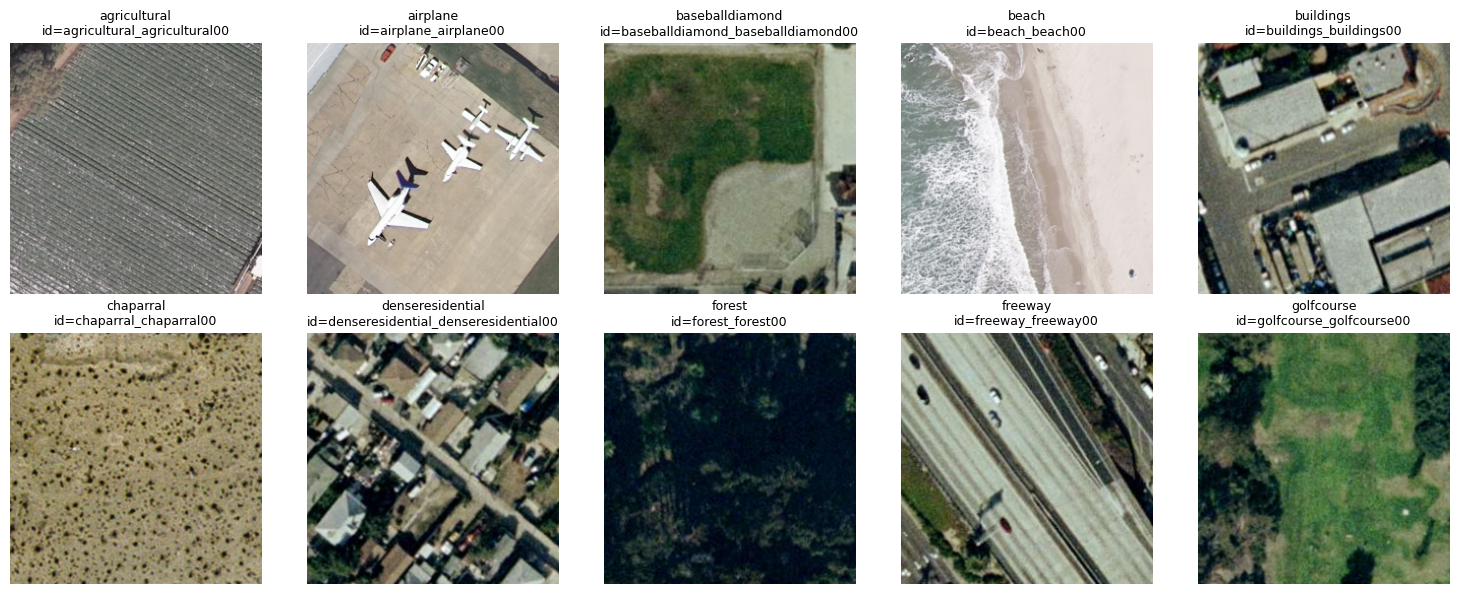

In [4]:
import io
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

#config
PARQUET_PATH     = "raw_samples/samples_raw.parquet"
CLASS_COL        = "class_name"
IMAGE_COL        = "image_bytes"
SAMPLE_ID_COL    = "sample_id"   

CLASSES_PER_ROW  = 5
MAX_CLASSES      = 10            # None = toutes les classes 
MODE             = "first"       # "first" ou "random"
SEED             = 42            # utilisé si MODE == "random"


def decode_image_bytes(b) -> Image.Image:
    return Image.open(io.BytesIO(b)).convert("RGB")

df = pd.read_parquet(PARQUET_PATH, columns=[CLASS_COL, IMAGE_COL, SAMPLE_ID_COL])

classes = sorted(df[CLASS_COL].dropna().astype(str).unique().tolist())
if MAX_CLASSES is not None:
    classes = classes[:MAX_CLASSES]

if MODE == "random":
    rng = SEED
    pick_one = lambda g: g.sample(1, random_state=rng).iloc[0]
else:
    pick_one = lambda g: g.iloc[0]

images, titles = [], []
for cname in classes:
    g = df[df[CLASS_COL] == cname]
    if g.empty:
        continue
    row = pick_one(g)
    img = decode_image_bytes(row[IMAGE_COL])
    images.append(img)
    titles.append(f"{cname}\nid={row[SAMPLE_ID_COL]}")
n = len(images)
if n == 0:
    print("Aucune image à afficher.")
else:
    rows = math.ceil(n / CLASSES_PER_ROW)
    fig, axes = plt.subplots(rows, CLASSES_PER_ROW, figsize=(CLASSES_PER_ROW*3, rows*3))
    axes = np.atleast_1d(axes).ravel()  

    for i in range(rows * CLASSES_PER_ROW):
        ax = axes[i]
        if i < n:
            ax.imshow(images[i])
            ax.set_title(titles[i], fontsize=9)
            ax.axis("off")
        else:
            ax.axis("off")

    plt.tight_layout()
    plt.show()


## Sampling

### 1. Corrupted sampling

##### Un seule transformation - afficher plusieurs images avec des niveaux de transformations différentes

In [5]:
import math
from io import BytesIO

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Choisir le fichier parquet à afficher 

ORIGINAL_PARQUET  = "raw_samples/samples_raw.parquet"
AUGMENTED_PARQUET = "raw_samples/augmented_brightness/transform_name=brightness/96f55eafe1b34e32a80710f562685623-0.parquet"
#AUGMENTED_PARQUET = "/Users/checkkoutame/Desktop/Renare/Samplesgen/output/augmented_ds/transform_name=color_temperature/b2ceaefd52d340e197f04d05a5961678-0.parquet"
#AUGMENTED_PARQUET = "/Users/checkkoutame/Desktop/Renare/Samplesgen/output/augmented_ds/transform_name=contrast/b2ceaefd52d340e197f04d05a5961678-0.parquet"
#AUGMENTED_PARQUET = "/Users/checkkoutame/Desktop/Renare/Samplesgen/output/augmented_ds/transform_name=sun_glare/b2ceaefd52d340e197f04d05a5961678-0.parquet"
#AUGMENTED_PARQUET = "/Users/checkkoutame/Desktop/Renare/Samplesgen/output/augmented_ds/transform_name=snow/b2ceaefd52d340e197f04d05a5961678-0.parquet"
#AUGMENTED_PARQUET = "/Users/checkkoutame/Desktop/Renare/Samplesgen/output/augmented_ds/transform_name=shadows/b2ceaefd52d340e197f04d05a5961678-0.parquet"
#AUGMENTED_PARQUET = "/Users/checkkoutame/Desktop/Renare/Samplesgen/output/augmented_ds/transform_name=rain/b2ceaefd52d340e197f04d05a5961678-0.parquet"
#AUGMENTED_PARQUET = "/Users/checkkoutame/Desktop/Renare/Samplesgen/output/augmented_ds/transform_name=fog/b2ceaefd52d340e197f04d05a5961678-0.parquet"
#AUGMENTED_PARQUET = "/Users/checkkoutame/Desktop/Renare/Samplesgen/output/augmented_ds/transform_name=occlusion/b2ceaefd52d340e197f04d05a5961678-0.parquet"

orig_df = pd.read_parquet(ORIGINAL_PARQUET)
aug_df  = pd.read_parquet(AUGMENTED_PARQUET)

TARGET_CLASS_NAMES = ["river","agricultural"]  # [] = toutes les classes
N_LEVELS        = 6        # nb de niveaux à afficher pour le sample principal
MAX_CLASSES     = 6        # limite d'affichage des classes (None = toutes)
SHOW_ORIGINAL   = True     # afficher l'image d'origine
EXTRA_SAMPLES   = 3        # nb d'autres samples (min & max)

IMAGES_PER_ROW  = 5        #nombre d'images par ligne (grille)

def decode_image_bytes(b) -> Image.Image:
    return Image.open(BytesIO(b)).convert("RGB")

def pick_levels_sorted(levels, n):
    """Prend n niveaux espacés (inclut min & max), tri croissant."""
    levels = sorted(pd.Series(levels).dropna().unique().tolist())
    if n is None or len(levels) <= n:
        return levels
    idxs = [round(i * (len(levels) - 1) / (n - 1)) for i in range(n)]
    seen, picked = set(), []
    for i in idxs:
        if i not in seen:
            picked.append(i); seen.add(i)
    return [levels[i] for i in picked]

def closest_rows_to_targets(df_levels: pd.DataFrame, targets):

    if "transform_level" not in df_levels.columns or df_levels.empty:
        return []
    lv = pd.to_numeric(df_levels["transform_level"], errors="coerce")
    out = []
    for t in targets:
        diffs = (lv - float(t)).abs()
        if diffs.notna().any():
            idx = diffs.idxmin()
            out.append(df_levels.loc[idx])
    return out

def choose_common_sample_id(orig_c: pd.DataFrame, aug_c: pd.DataFrame):
    if "sample_id" not in orig_c.columns or "sample_id" not in aug_c.columns:
        return None
    commons = sorted(set(orig_c["sample_id"]).intersection(set(aug_c["sample_id"])))
    return commons[0] if commons else None



if TARGET_CLASS_NAMES and "class_name" in orig_df.columns:
    orig_df = orig_df[orig_df["class_name"].isin(TARGET_CLASS_NAMES)]
if TARGET_CLASS_NAMES and "class_name" in aug_df.columns:
    aug_df = aug_df[aug_df["class_name"].isin(TARGET_CLASS_NAMES)]

# classes à traiter
if "class_name" in orig_df.columns:
    classes = sorted(orig_df["class_name"].dropna().astype(str).unique().tolist())
else:
    classes = ["_all_"]

if MAX_CLASSES is not None:
    classes = classes[:MAX_CLASSES]

for cls in classes:
    if cls != "_all_":
        orig_c = orig_df[orig_df["class_name"] == cls]
        aug_c  = aug_df[aug_df["class_name"] == cls]
    else:
        orig_c, aug_c = orig_df, aug_df

    if orig_c.empty or aug_c.empty:
        continue

    # sample principal commun
    sel_sample_id = choose_common_sample_id(orig_c, aug_c)
    if sel_sample_id is not None:
        row_orig = orig_c[orig_c["sample_id"] == sel_sample_id].iloc[0]
        g_main = aug_c[aug_c["sample_id"] == sel_sample_id].copy()
    else:
        row_orig = orig_c.iloc[0]
        if "sample_id" in aug_c.columns and "sample_id" in row_orig:
            g_main = aug_c[aug_c["sample_id"] == row_orig["sample_id"]].copy()
        else:
            g_main = aug_c.copy()

    # niveaux pour le sample principal
    if "transform_level" in g_main.columns:
        g_main = g_main.sort_values("transform_level", ascending=True)
        chosen_levels = pick_levels_sorted(g_main["transform_level"], N_LEVELS)
        g_main = g_main[g_main["transform_level"].isin(chosen_levels)].sort_values("transform_level", ascending=True)
    else:
        g_main = g_main.head(N_LEVELS or len(g_main))

    # cibles min/max sur la classe
    targets = []
    if "transform_level" in aug_c.columns:
        lv_all = pd.to_numeric(aug_c["transform_level"], errors="coerce").dropna()
        if not lv_all.empty:
            targets = [float(lv_all.min()), float(lv_all.max())]

    images, titles = [], []

    if SHOW_ORIGINAL and "image_bytes" in row_orig and pd.notna(row_orig["image_bytes"]):
        try:
            im0 = decode_image_bytes(row_orig["image_bytes"])
            sid = row_orig.get("sample_id", "idx0")
            images.append(im0)
            #titles.append(f"Original ({cls}) | id={sid}")
            titles.append(f"Original ({cls})\nid={sid}")
        except Exception:
            pass

    for _, r in g_main.iterrows():
        if "image_bytes" in r and pd.notna(r["image_bytes"]):
            try:
                im = decode_image_bytes(r["image_bytes"])
                lvl = r.get("transform_level", "?")
                tname = r.get("transform_name", "transform")
                images.append(im)
                #titles.append(f"{tname} | lvl={lvl}")
                titles.append(f"id={r.get('sample_id', '?')}\n{tname} | lvl={lvl}")
            except Exception:
                pass

    # extras : autres sample_id (min & max)
    if targets and EXTRA_SAMPLES > 0 and "sample_id" in aug_c.columns:
        commons = sorted(set(orig_c["sample_id"]).intersection(set(aug_c["sample_id"])))
        extras = [sid for sid in commons if sid != sel_sample_id][:EXTRA_SAMPLES]
        for sid in extras:
            g_sid = aug_c[aug_c["sample_id"] == sid]
            rows_extremes = closest_rows_to_targets(g_sid, targets)
            seen = set()
            for rr in rows_extremes:
                if rr.name in seen:
                    continue
                seen.add(rr.name)
                if "image_bytes" in rr and pd.notna(rr["image_bytes"]):
                    try:
                        im = decode_image_bytes(rr["image_bytes"])
                        lvl = rr.get("transform_level", "?")
                        tname = rr.get("transform_name", "transform")
                        images.append(im)
                        #titles.append(f"id={sid} | {tname} | lvl={lvl}")
                        titles.append(f"id={sid}\n{tname} | lvl={lvl}")
                    except Exception:
                        pass

    if not images:
        continue

    n_total = len(images)
    ncols = int(IMAGES_PER_ROW)
    nrows = math.ceil(n_total / ncols)

    #print(f"[{cls}] images affichées: {n_total} | {ncols} par ligne -> {nrows} ligne(s)")

    plt.figure(figsize=(4 * ncols, 4 * nrows))
    for i, (im, title) in enumerate(zip(images, titles), start=1):
        ax = plt.subplot(nrows, ncols, i)
        ax.imshow(im)
        ax.set_title(title)
        ax.axis("off")

    plt.suptitle(
        f"Classe: {cls}",
        fontsize=16,
        y=0.995
    )
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'raw_samples/augmented_brightness/transform_name=brightness/96f55eafe1b34e32a80710f562685623-0.parquet'

##### Toutes les transformations pour une même iamge

/var/folders/hw/s6q37kzd6l7bvch2rztj09lw0000gn/T/ipykernel_38172/1743300410.py:85: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby("transform_name", sort=False)


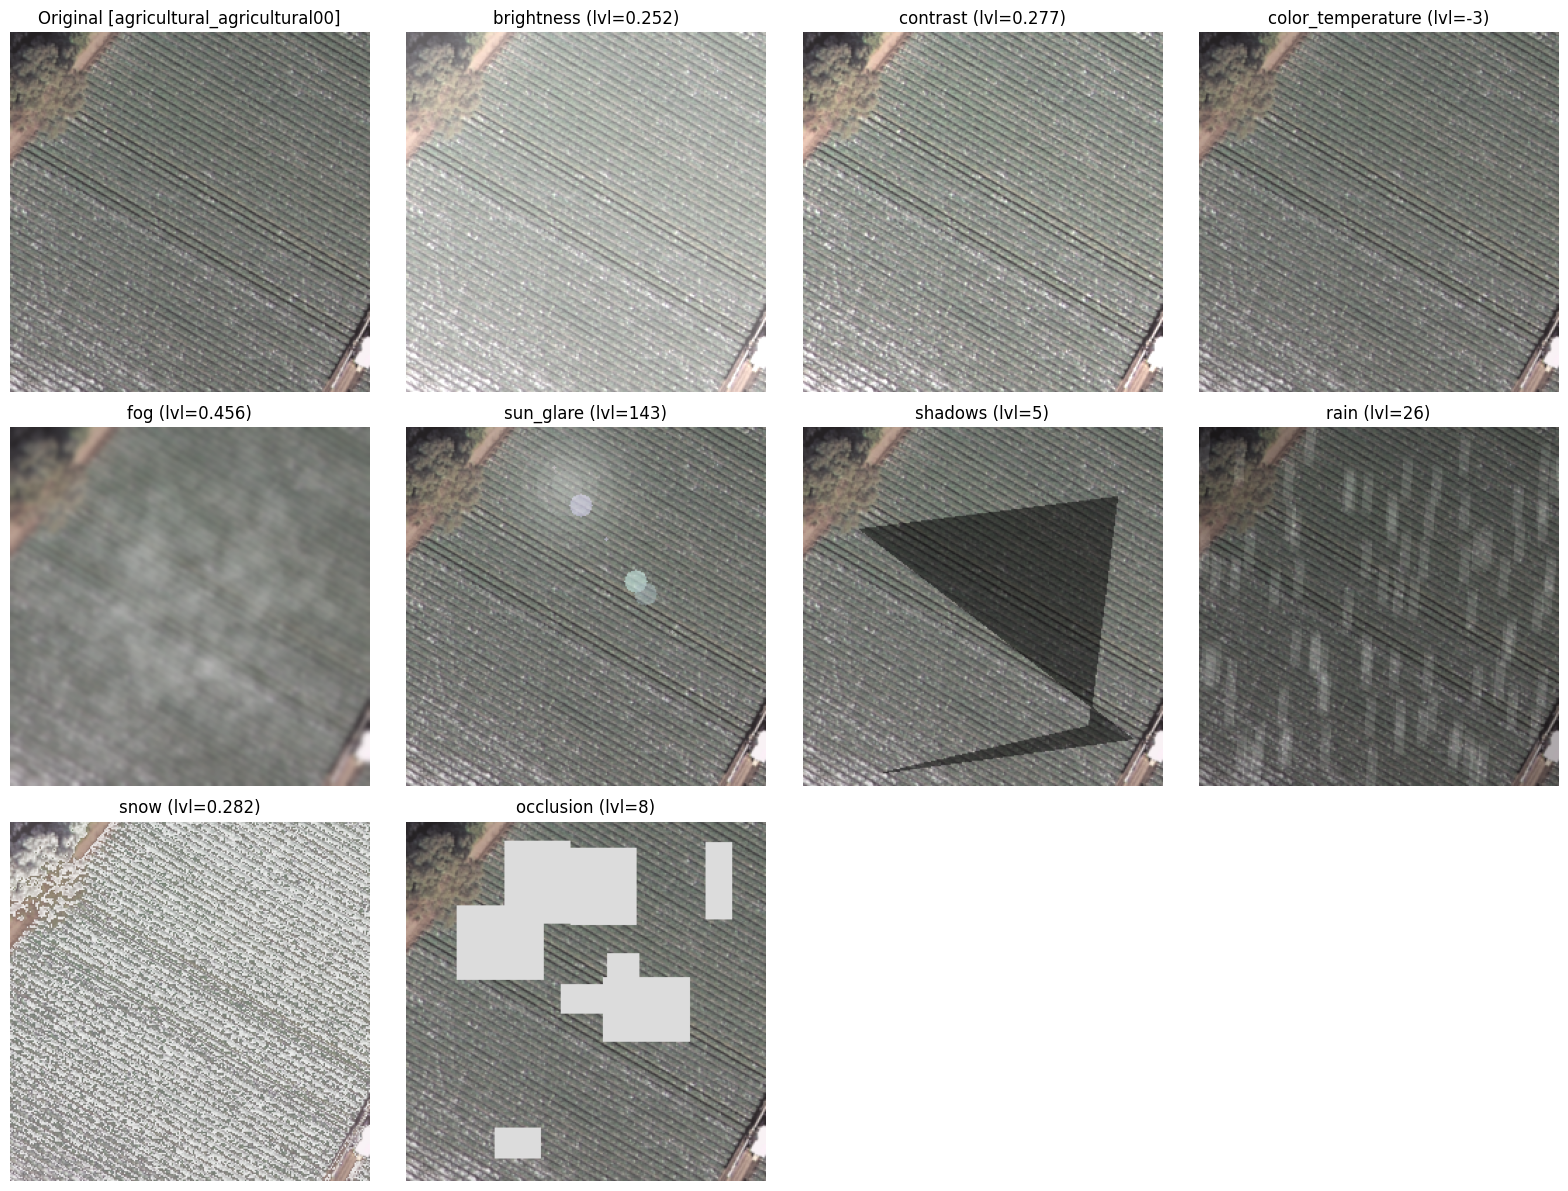

In [15]:
import os, math, json, base64
from io import BytesIO
from typing import List, Optional, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# path à adapter
ORIGINAL_PARQUET  = "/Users/checkkoutame/Desktop/Renare/kc-data-sampling/input/samples_raw.parquet"
AUGMENTED_DATASET_ROOT = "/Users/checkkoutame/Desktop/Renare/kc-data-sampling/output/augmented_ds"  # dossier partitionné
ORIGINAL_BASE_DIR = None  # si tes file_path sont relatifs, sinon None

# affichage
TARGET_CLASS_NAMES: Optional[Sequence[str]] = None  # prendre ["river","agricultural"] ou None
TARGET_CLASS_IDS:   Optional[Sequence[int]] = None  # ex: [0,1] ou None 
TARGET_PARENT_ID:   Optional[str] = None            # si None: prend le 1er trouvable 
MAX_PER_TRANSFORM = 5                              # nb d'images à afficher par transformation
TRANSFORMS_INCLUDE: Optional[Sequence[str]] = None  # ex: ["brightness","contrast"] (utilise alias ou transform_name). None = toutes
SHUFFLE = True                                      # mélanger les exemples par transfo
RANDOM_STATE = 0

def _bytes_from_maybe_str(b):
    if isinstance(b, bytes):
        return b
    # if isinstance(b, str):
    #     try:
    #         return b.encode("latin1")
    #     except Exception:
    #         return base64.b64decode(b)
    # raise ValueError("Unsupported image_bytes format")

def row_to_pil(row, prefer_bytes=True, base_dir=None) -> Image.Image:
    if prefer_bytes and "image_bytes" in row and pd.notna(row["image_bytes"]):
        return Image.open(BytesIO(_bytes_from_maybe_str(row["image_bytes"]))).convert("RGB")
    # if "file_path" in row and pd.notna(row["file_path"]):
    #     fp = str(row["file_path"])
    #     if base_dir and not os.path.isabs(fp):
    #         fp = os.path.join(base_dir, fp)
    #     return Image.open(fp).convert("RGB")
    # raise ValueError("Row has neither valid image_bytes nor file_path")

def _read_original_df(path: str) -> pd.DataFrame:
    return pd.read_parquet(path)

def _read_augmented_for_parent(root: str, parent_id: str) -> pd.DataFrame:
    try:
        return pd.read_parquet(root, engine="pyarrow", filters=[("sample_id","==", parent_id)])
    except Exception:
        df = pd.read_parquet(root)
        return df[df["sample_id"] == parent_id]

def choose_target_parent(aug_df: pd.DataFrame) -> str:
    parents = aug_df["sample_id"].dropna().unique()
    if len(parents) == 0:
        raise RuntimeError("No parents found after filtering.")
    return str(parents[0])

def filter_aug_by_class(df: pd.DataFrame) -> pd.DataFrame:
    mask = pd.Series(True, index=df.index)
    if TARGET_CLASS_NAMES:
        mask &= df["class_name"].isin(TARGET_CLASS_NAMES)
    if TARGET_CLASS_IDS:
        mask &= df["class_id"].isin(TARGET_CLASS_IDS)
    return df[mask]

def pick_examples_by_transform(aug_df: pd.DataFrame, per_transform: int, transforms_include=None, shuffle=True, random_state=0):

    rows = []
    df = aug_df.copy()

    if "transform_name" not in df.columns:
        raise ValueError("augmented dataset must contain 'transform_name' column")

    if transforms_include:

        df = df[df["transform_name"].isin(transforms_include)]

    if "transform_id" in df.columns:
        df = df.sort_values(["transform_id", "transform_level"], na_position="last")
    else:
        df = df.sort_values(["transform_name", "transform_level"], na_position="last")

    g = df.groupby("transform_name", sort=False)
    rng = np.random.default_rng(random_state)

    for tname, gdf in g:
        if shuffle:
            idx = gdf.index.to_numpy()
            rng.shuffle(idx)
            gpick = gdf.loc[idx[:per_transform]]
        else:
            gpick = gdf.head(per_transform)

        for _, r in gpick.iterrows():
            lvl = r.get("transform_level", None)
            if pd.isna(lvl):
                lvl_str = "-"
            else:
                if isinstance(lvl, (int, np.integer)) or (isinstance(lvl, float) and float(lvl).is_integer()):
                    lvl_str = f"{int(float(lvl))}"
                else:
                    lvl_str = f"{float(lvl):.3f}"

            title = f"{tname} (lvl={lvl_str})"
            rows.append((r, title))

    return rows

def show_grid_for_parent(orig_df: pd.DataFrame, aug_df_parent: pd.DataFrame, parent_id: str, per_transform: int = 2, transforms_include=None):
    orig_row = orig_df[orig_df["sample_id"] == parent_id]
    if len(orig_row) == 0:
        raise RuntimeError(f"Original not found for sample_id={parent_id}")
    orig_img = row_to_pil(orig_row.iloc[0], prefer_bytes=True, base_dir=ORIGINAL_BASE_DIR)

    picks = pick_examples_by_transform(
        aug_df_parent,
        per_transform=per_transform,
        transforms_include=transforms_include,
        shuffle=SHUFFLE,
        random_state=RANDOM_STATE
    )

    tiles = []
    tiles.append((orig_img, f"Original [{parent_id}]"))
    for r, title in picks:
        tiles.append((row_to_pil(r, prefer_bytes=True), title))

    # Affichage
    n = len(tiles)
    ncols = 4
    nrows = math.ceil(n / ncols)
    fig = plt.figure(figsize=(4*ncols, 4*nrows))

    for i, (img, title) in enumerate(tiles, start=1):
        ax = fig.add_subplot(nrows, ncols, i)
        ax.imshow(img)
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

def main():

    orig_df = _read_original_df(ORIGINAL_PARQUET)
    if TARGET_PARENT_ID is None:
        all_aug = pd.read_parquet(AUGMENTED_DATASET_ROOT)
        all_aug = filter_aug_by_class(all_aug)
        candidate_parent = choose_target_parent(all_aug)
        del all_aug
    else:
        candidate_parent = TARGET_PARENT_ID

    aug_parent = _read_augmented_for_parent(AUGMENTED_DATASET_ROOT, candidate_parent)
    aug_parent = filter_aug_by_class(aug_parent)

    if len(aug_parent) == 0:
        raise RuntimeError(f"No augmented rows found for sample_id={candidate_parent} after filtering.")

    show_grid_for_parent(
        orig_df=orig_df,
        aug_df_parent=aug_parent,
        parent_id=candidate_parent,
        per_transform=MAX_PER_TRANSFORM,
        transforms_include=TRANSFORMS_INCLUDE
    )

if __name__ == "__main__":
    main()


### 2. Adversarial sampling

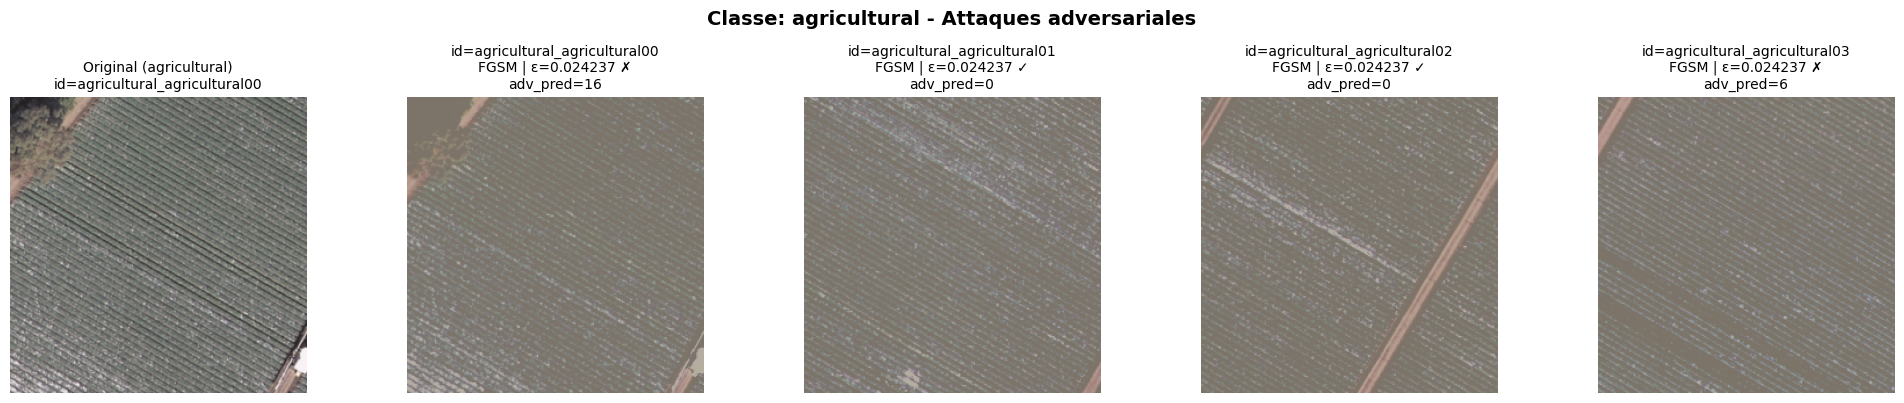

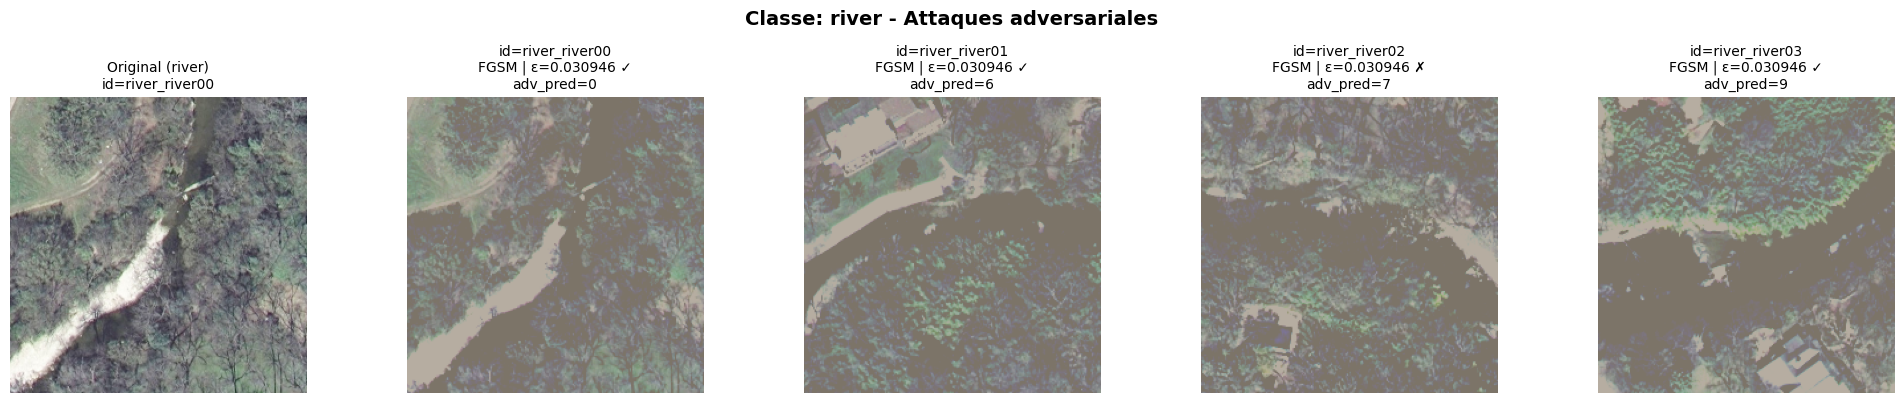

Affichage terminé!


In [ ]:
import math
from io import BytesIO

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Configuration pour les images adversariales
ORIGINAL_PARQUET  = "/Users/checkkoutame/Desktop/Renare/kc-data-sampling/input/samples.parquet"
ADVERSARIAL_PARQUET = "/Users/checkkoutame/Desktop/Renare/kc-data-sampling/output/adversarial_ds/transform_name=fgsm/2053dae37de647e493b7316b1ee30b57-0.parquet"

orig_df = pd.read_parquet(ORIGINAL_PARQUET)
adv_df  = pd.read_parquet(ADVERSARIAL_PARQUET)

TARGET_CLASS_NAMES = ["river", "agricultural"]  # [] = toutes les classes
N_LEVELS        = 6        # nb de niveaux à afficher pour le sample principal
MAX_CLASSES     = 6        # limite d'affichage des classes (None = toutes)
SHOW_ORIGINAL   = True     # afficher l'image d'origine
EXTRA_SAMPLES   = 3        # nb d'autres samples (min & max)

IMAGES_PER_ROW  = 5        # nombre d'images par ligne (grille)

def decode_image_bytes(b) -> Image.Image:
    return Image.open(BytesIO(b)).convert("RGB")

def pick_levels_sorted(levels, n):
    """Prend n niveaux espacés (inclut min & max), tri croissant."""
    levels = sorted(pd.Series(levels).dropna().unique().tolist())
    if n is None or len(levels) <= n:
        return levels
    idxs = [round(i * (len(levels) - 1) / (n - 1)) for i in range(n)]
    seen, picked = set(), []
    for i in idxs:
        if i not in seen:
            picked.append(i); seen.add(i)
    return [levels[i] for i in picked]

def closest_rows_to_targets(df_levels: pd.DataFrame, targets):
    if "transform_level" not in df_levels.columns or df_levels.empty:
        return []
    lv = pd.to_numeric(df_levels["transform_level"], errors="coerce")
    out = []
    for t in targets:
        diffs = (lv - float(t)).abs()
        if diffs.notna().any():
            idx = diffs.idxmin()
            out.append(df_levels.loc[idx])
    return out

def choose_common_sample_id(orig_c: pd.DataFrame, adv_c: pd.DataFrame):
    if "sample_id" not in orig_c.columns or "sample_id" not in adv_c.columns:
        return None
    commons = sorted(set(orig_c["sample_id"]).intersection(set(adv_c["sample_id"])))
    return commons[0] if commons else None

# Filtrage par classe si demandé
if TARGET_CLASS_NAMES and "class_name" in orig_df.columns:
    orig_df = orig_df[orig_df["class_name"].isin(TARGET_CLASS_NAMES)]
if TARGET_CLASS_NAMES and "class_name" in adv_df.columns:
    adv_df = adv_df[adv_df["class_name"].isin(TARGET_CLASS_NAMES)]

# Classes à traiter
if "class_name" in orig_df.columns:
    classes = sorted(orig_df["class_name"].dropna().astype(str).unique().tolist())
else:
    classes = ["_all_"]

if MAX_CLASSES is not None:
    classes = classes[:MAX_CLASSES]

for cls in classes:
    if cls != "_all_":
        orig_c = orig_df[orig_df["class_name"] == cls]
        adv_c  = adv_df[adv_df["class_name"] == cls]
    else:
        orig_c, adv_c = orig_df, adv_df

    if orig_c.empty or adv_c.empty:
        continue

    # Sample principal commun
    sel_sample_id = choose_common_sample_id(orig_c, adv_c)
    if sel_sample_id is not None:
        row_orig = orig_c[orig_c["sample_id"] == sel_sample_id].iloc[0]
        g_main = adv_c[adv_c["sample_id"] == sel_sample_id].copy()
    else:
        row_orig = orig_c.iloc[0]
        if "sample_id" in adv_c.columns and "sample_id" in row_orig:
            g_main = adv_c[adv_c["sample_id"] == row_orig["sample_id"]].copy()
        else:
            g_main = adv_c.copy()

    # Niveaux pour le sample principal (transform_level = epsilon pour adversarial)
    if "transform_level" in g_main.columns:
        g_main = g_main.sort_values("transform_level", ascending=True)
        chosen_levels = pick_levels_sorted(g_main["transform_level"], N_LEVELS)
        g_main = g_main[g_main["transform_level"].isin(chosen_levels)].sort_values("transform_level", ascending=True)
    else:
        g_main = g_main.head(N_LEVELS or len(g_main))

    # Cibles min/max sur la classe
    targets = []
    if "transform_level" in adv_c.columns:
        lv_all = pd.to_numeric(adv_c["transform_level"], errors="coerce").dropna()
        if not lv_all.empty:
            targets = [float(lv_all.min()), float(lv_all.max())]

    images, titles = [], []

    # Image originale
    if SHOW_ORIGINAL and "image_bytes" in row_orig and pd.notna(row_orig["image_bytes"]):
        try:
            im0 = decode_image_bytes(row_orig["image_bytes"])
            sid = row_orig.get("sample_id", "idx0")
            images.append(im0)
            titles.append(f"Original ({cls})\nid={sid}")
        except Exception as e:
            print(f"Erreur décodage original: {e}")

    # Images adversariales du sample principal
    for _, r in g_main.iterrows():
        if "image_bytes" in r and pd.notna(r["image_bytes"]):
            try:
                im = decode_image_bytes(r["image_bytes"])
                eps = r.get("transform_level", "?")
                attack = "FGSM"
                pred = r.get("adv_pred", "?")
                is_success = r.get("is_success", False)
                success_marker = "✓" if is_success else "✗"
                images.append(im)
                titles.append(f"id={r.get('sample_id', '?')}\n{attack} | ε={eps} {success_marker}\nadv_pred={pred}")
            except Exception as e:
                print(f"Erreur décodage adversarial: {e}")

    # Extras : autres sample_id (min & max epsilon)
    if targets and EXTRA_SAMPLES > 0 and "sample_id" in adv_c.columns:
        commons = sorted(set(orig_c["sample_id"]).intersection(set(adv_c["sample_id"])))
        extras = [sid for sid in commons if sid != sel_sample_id][:EXTRA_SAMPLES]
        for sid in extras:
            g_sid = adv_c[adv_c["sample_id"] == sid]
            rows_extremes = closest_rows_to_targets(g_sid, targets)
            seen = set()
            for rr in rows_extremes:
                if rr.name in seen:
                    continue
                seen.add(rr.name)
                if "image_bytes" in rr and pd.notna(rr["image_bytes"]):
                    try:
                        im = decode_image_bytes(rr["image_bytes"])
                        eps = rr.get("transform_level", "?")
                        attack = "FGSM"
                        pred = rr.get("adv_pred", "?")
                        is_success = rr.get("is_success", False)
                        success_marker = "✓" if is_success else "✗"
                        images.append(im)
                        titles.append(f"id={sid}\n{attack} | ε={eps} {success_marker}\nadv_pred={pred}")
                    except Exception as e:
                        print(f"Erreur décodage extra: {e}")

    if not images:
        continue

    n_total = len(images)
    ncols = int(IMAGES_PER_ROW)
    nrows = math.ceil(n_total / ncols)

    plt.figure(figsize=(4 * ncols, 4 * nrows))
    for i, (im, title) in enumerate(zip(images, titles), start=1):
        ax = plt.subplot(nrows, ncols, i)
        ax.imshow(im)
        ax.set_title(title, fontsize=10)
        ax.axis("off")

    plt.suptitle(
        f"Classe: {cls} - Attaques adversariales",
        y=0.995,
        fontsize=14,
        fontweight='bold'
    )
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

